# Лабораторная работа №3  
## Поиск локальных экстремумов функции с помощью градиентных методов  

**Цель работы:**  
Изучить аналитические и численные методы нахождения локальных экстремумов функций, используя градиентные методы.  
Научиться строить линии уровня, вычислять градиент и реализовывать градиентные спуски различных типов.

**Выполнил:** *Воронин Илья Андреевич* 
**Группа:** *J3212*
**Ису:** *372736*

## Теоретическая часть

1. **Градиент функции** — это вектор, показывающий направление наискорейшего возрастания функции:
   
   $$ \nabla f(x, y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right) $$

   Направление **антиградиента** $-\nabla f$ указывает путь наискорейшего убывания функции.

2. **Стационарная точка** — это точка, где градиент равен нулю:
   
   $$ \nabla f(x, y) = 0 $$

3. **Матрица Гессе** — квадратная матрица вторых производных функции:
   
   $$ 
   H(f)(x, y) =
   \begin{pmatrix}
   \dfrac{\partial^2 f}{\partial x^2} & \dfrac{\partial^2 f}{\partial x \partial y} \\
   \dfrac{\partial^2 f}{\partial y \partial x} & \dfrac{\partial^2 f}{\partial y^2}
   \end{pmatrix}
   $$

   По знакам собственных значений матрицы Гессе можно определить тип точки:
   - оба положительные → **локальный минимум**,
   - оба отрицательные → **локальный максимум**,
   - разные знаки → **седловая точка**.

4. **Метод градиентного спуска**:
   
   $$ x_{k+1} = x_k - \alpha_k \, \nabla f(x_k) $$

   где $\alpha_k$ — шаг (скорость обучения).

   - Малый шаг → медленная сходимость.  
   - Большой шаг → метод может расходиться.

## Аналитическая часть  

Исследуем функцию:

$$ f(x, y) = x^2y - \frac{1}{3}y^3 - x^2 - y^2 $$

Найдем стационарные точки, матрицу Гессе и определим их тип.

In [2]:
import sympy as sp

x, y = sp.symbols('x y')

F = x**2*y - 1/3*y**3 - x**2 - y**2
# Частные производные
Fx = sp.diff(F, x)
Fy = sp.diff(F, y)

Fx, Fy


(2*x*y - 2*x, x**2 - 1.0*y**2 - 2*y)

In [3]:
# Стационарные точки
station_points = sp.solve([Fx, Fy], (x, y))
station_points

[(-1.73205080756888, 1.00000000000000),
 (0.0, -2.00000000000000),
 (0.0, 0.0),
 (1.73205080756888, 1.00000000000000)]

In [4]:
# Матрица Гессе
H = sp.hessian(F, (x, y))
H

Matrix([
[2*y - 2,        2*x],
[    2*x, -2.0*y - 2]])

In [5]:
# Проверим типы стационарных точек
for point in station_points:
    H_val = H.subs({x: point[0], y: point[1]})
    eigenvals = H_val.eigenvals()
    print(f"Точка {point}")
    print(f"Собственные значения Гессе: {list(eigenvals.keys())}\n")

Точка (-1.73205080756888, 1.00000000000000)
Собственные значения Гессе: [2.00000000000000, -6.00000000000000]

Точка (0.0, -2.00000000000000)
Собственные значения Гессе: [-6.00000000000000, 2.00000000000000]

Точка (0.0, 0.0)
Собственные значения Гессе: [-2]

Точка (1.73205080756888, 1.00000000000000)
Собственные значения Гессе: [2.00000000000000, -6.00000000000000]



**Вывод:**
- Точка (-1.7, 1) - собственные значения не имеют общего знака => седловая точка.
- Точка (0, -2) - аналогичная ситуация - седловая точка.
- Точка (0, 0) - собственное значение одна, меньше 0 => локальный максимум
- Точка (1.7, 1) - собственные значения не имеют общего знака => седловая точка


### Проверка подозрительных точек по определению экстремума

Если матрица Гессе в стационарной точке даёт собственные значения разных знаков, то признак второго порядка не говорит о минимуме или максимуме. В этом случае нужно проверить точку по определению экстремума.

**Определение локального минимума.**  
Точка $(x_0, y_0)$ называется локальным минимумом, если существует такая достаточно маленькая окрестность этой точки, что для любых $(x, y)$ из этой окрестности
$$
f(x, y) \ge f(x_0, y_0).
$$

**Определение локального максимума.**  
Точка $(x_0, y_0)$ — локальный максимум, если в некоторой окрестности
$$
f(x, y) \le f(x_0, y_0).
$$

Если вблизи точки можно найти направления, где значение функции возрастает, и направления, где оно убывает, то точка не может быть ни минимумом, ни максимумом. Такая точка называется **седловой точкой**.

---

Рассмотрим для нашей функции  
$$
f(x, y) = x^2 y - \frac{1}{3} y^3 - x^2 - y^2
$$
в стационарной точке $(0,\,-2)$.

1. **Двигаемся только по $x$**, фиксируя $y = -2$.  
   То есть рассматриваем одномерную функцию:

   $$ g(x) = f(x, -2). $$

   Подставим $y = -2$:

   $$
   \begin{aligned}
   f(x, -2) &= x^2 \cdot (-2) - \frac{1}{3}(-2)^3 - x^2 - (-2)^2 \\
            &= -2x^2 + \frac{8}{3} - x^2 - 4 \\
            &= -3x^2 - \frac{4}{3}.
   \end{aligned}
   $$

   Это парабола с коэффициентом $-3$ перед $x^2$,  
   то есть ветви направлены вниз.  
   Значит если мы немного сдвигаемся от $x = 0$, значение функции уменьшается —  
   функция убывает вдоль оси $x$.

2. Теперь двигаемся только по $y$, фиксируя $x = 0$.  
   Рассмотрим
   $$
   h(y) = f(0, y) = 0 - \frac{1}{3} y^3 - 0 - y^2
   = -\frac{1}{3} y^3 - y^2.
   $$

   Если мы берём $y$ не ровно $-2$, а $y = -2 + \delta$, то изменение функции уже не чисто квадратичное, там появляется кубический член $-\frac{1}{3} y^3$, из-за которого график ведёт себя не так, как вдоль оси $x$. Можно подобрать $\delta$ так, что функция будет расти.

**Вывод:** в окрестности точки $(0, -2)$ есть направление, где функция уменьшается (по $x$), и направление, где функция увеличивается (по $y$). Значит эту точку нельзя назвать ни минимумом, ни максимумом. Это **седловая точка**.

То же самое для точек $(\sqrt{3}, 1)$ и $(-\sqrt{3}, 1)$: там тоже есть направления, где функция растёт, и направления, где она падает. Поэтому это тоже седловые точки.

## Практическая часть

### 1. Построить график функции и линии уровня. Отметить стационарные точки. При необходимости сузить область.

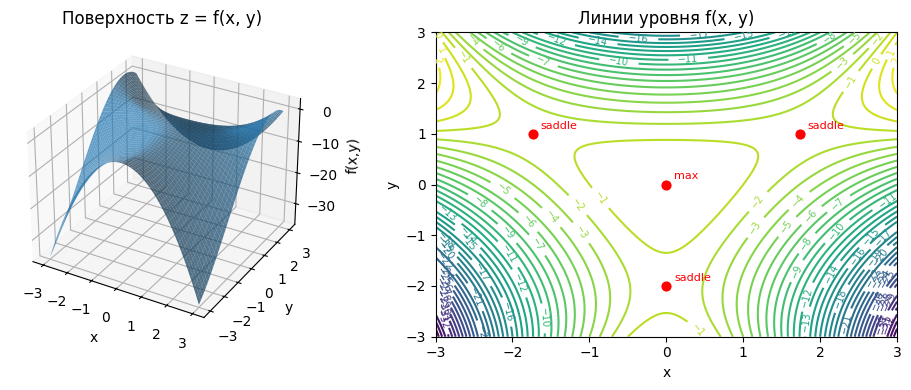

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x, y):
    return x**2 * y - (1/3)*y**3 - x**2 - y**2

xs = np.linspace(-3, 3, 200)
ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.7)
ax1.set_title("Поверхность z = f(x, y)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x,y)")

ax2 = fig.add_subplot(1,2,2)
CS = ax2.contour(X, Y, Z, levels=40)
ax2.clabel(CS, inline=True, fontsize=7)
ax2.set_title("Линии уровня f(x, y)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

pts = [
    (0, 0, "max"),
    (0, -2, "saddle"),
    (np.sqrt(3), 1, "saddle"),
    (-np.sqrt(3), 1, "saddle")
]

for (px, py, label) in pts:
    ax2.scatter(px, py, c='red', s=40)
    ax2.text(px+0.1, py+0.1, label, color='red', fontsize=8)

plt.tight_layout()
plt.show()

### 2. Покажите, что направление наискорейшего возрастания функции совпадает с направлением градиента функции, а убывания – с направлением антиградиента.

Градиент функции:
$$
\nabla f(x,y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
= (2xy - 2x,\; x^2 - y^2 - 2y).
$$

Факт из теории:
- Вектор $\nabla f(x,y)$ указывает направление, в котором функция $f$ растёт быстрее всего.
- Вектор $-\nabla f(x,y)$ указывает направление наискорейшего убывания.

Интуитивно: пусть мы делаем маленький шаг $\Delta \vec{r}$ от точки $(x,y)$.  
Приращение функции приблизительно:
$$
\Delta f \approx \nabla f(x,y) \cdot \Delta \vec{r}.
$$

Скалярное произведение максимально, когда $\Delta \vec{r}$ сонаправлен с $\nabla f(x,y)$,  
и минимально, когда оно противонаправлено с $\nabla f(x,y)$.

То есть:
- градиент — это "стрелка вверх",
- антиградиент $-\nabla f$ — это "стрелка вниз".

Метод градиентного спуска использует именно $-\nabla f$, потому что мы ищем минимум.

### 3. При реализации методов рекомендуем заложить алгоритм запоминания всех точек приближения, а также количество итераций метода.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def f(x, y):
    return x**2 * y - (1/3)*y**3 - x**2 - y**2

def grad_f(x, y):
    df_dx = 2*x*y - 2*x
    df_dy = x**2 - y**2 - 2*y
    return np.array([df_dx, df_dy])

### 4a. Градиентный спуск с постоянным шагом

In [16]:
def gradient_descent_const(alpha=0.01, eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0])):
    """
    Метод градиентного спуска с постоянным шагом alpha.
    Остановка: ||grad|| < eps или достигли max_iter.
    """
    xk = x0.astype(float)
    points = [xk.copy()]
    for _ in range(max_iter):
        g = grad_f(*xk)
        if np.linalg.norm(g) < eps:
            break
        xk = xk - alpha * g
        points.append(xk.copy())
    return np.array(points), f(*xk)

pts_const, f_const = gradient_descent_const(alpha=0.00001)
print("Постоянный шаг:")
print("  Точка:", pts_const[-1])
print("  f =", f_const)
print("  итераций =", len(pts_const)-1)


Постоянный шаг:
  Точка: [1.54803993 2.66011413]
  f = -9.372370068780809
  итераций = 10000


### 4b. Градиентный спуск с уменьшающимся шагом

In [9]:
def gradient_descent_decay(alpha=0.05, decay=0.9, eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0])):
    """
    Градиентный спуск, где шаг уменьшается по мере итераций.
    alpha = alpha * decay каждый шаг.
    Это делает метод стабильнее ближе к минимуму.
    """
    xk = x0.astype(float)
    a = alpha
    points = [xk.copy()]
    for _ in range(max_iter):
        g = grad_f(*xk)
        if np.linalg.norm(g) < eps:
            break
        xk = xk - a * g
        points.append(xk.copy())
        a *= decay
    return np.array(points), f(*xk)

pts_decay, f_decay = gradient_descent_decay(alpha=0.005, decay=0.9)
print("Уменьшающийся шаг:")
print("  Точка:", pts_decay[-1])
print("  f =", f_decay)
print("  итераций =", len(pts_decay)-1)

Уменьшающийся шаг:
  Точка: [1.78933586 2.2527749 ]
  f = -4.874897004088552
  итераций = 10000


### 4c. Метод наискорейшего спуска (steepest descent)

In [10]:
def gradient_descent_optimal_safe(
    eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0]),
    alpha_max=1.0, step_norm_cap=1.0
):
    """
    Наискорейший спуск с ограниченным подбором шага и капом по длине шага.
    step_norm_cap говорит: не двигайся за одну итерацию дальше, чем на step_norm_cap.
    """
    xk = x0.astype(float)
    points = [xk.copy()]

    for _ in range(max_iter):
        g = grad_f(*xk)
        gnorm = np.linalg.norm(g)
        if gnorm < eps:
            break

        def phi(alpha):
            x_new = xk - alpha * g
            return f(*x_new)

        res = minimize_scalar(phi, bounds=(0, alpha_max), method='bounded')
        alpha_star = res.x

        step_vec = alpha_star * g
        step_len = np.linalg.norm(step_vec)

        if step_len > step_norm_cap:
            step_vec = step_vec * (step_norm_cap / step_len)

        xk = xk - step_vec
        points.append(xk.copy())

    return np.array(points), f(*xk)

pts_opt_safe, f_opt_safe = gradient_descent_optimal_safe(alpha_max=1.0, step_norm_cap=1.0)
print("Наискорейший спуск:")
print("  Точка:", pts_opt_safe[-1])
print("  f =", f_opt_safe)
print("  итераций =", len(pts_opt_safe)-1)

Наискорейший спуск:
  Точка: [2.81452392e-07 1.00015794e+04]
  f = -333591326551.88525
  итераций = 10000


### 4d. Метод Флетчера–Ривса (нелинейный сопряжённый градиент)

In [15]:
def fletcher_reeves(eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0]), alpha_max=1.0, step_norm_cap=1.0):
    """
    Метод Флетчера–Ривса (conjugate gradient в n=2).
    На каждой итерации мы считаем новое направление как
    d_{k} = -g_k + beta_k * d_{k-1}
    где beta_k = ||g_k||^2 / ||g_{k-1}||^2.
    Шаг по alpha опять берём через одномерную оптимизацию вдоль d_k.
    """
    xk = x0.astype(float)

    gk = grad_f(*xk)

    dk = -gk

    points = [xk.copy()]

    for _ in range(max_iter):

        gnorm = np.linalg.norm(gk)
        if gnorm < eps:
            break

        def phi(alpha):
            x_new = xk + alpha * dk
            return f(*x_new)

        res = minimize_scalar(phi, bounds=(0, alpha_max), method='bounded')
        alpha_star = res.x

        step_vec = alpha_star * dk
        step_len = np.linalg.norm(step_vec)

        if step_len > step_norm_cap:
            step_vec = step_vec * (step_norm_cap / step_len)

        xk = xk + step_vec
        points.append(xk.copy())

        g_next = grad_f(*xk)

        denom = np.linalg.norm(gk)**2
        if denom < 1e-30:
            beta = 0.0
        else:
            beta = (np.linalg.norm(g_next)**2) / denom

        if not np.isfinite(beta) or beta > 1e6:
            beta = 0.0

        dk = -g_next + beta * dk

        if (not np.all(np.isfinite(dk))) or np.linalg.norm(dk) > 1e6:
            dk = -g_next

        gk = g_next

    return np.array(points), f(*xk)

pts_fr_safe, f_fr_safe = fletcher_reeves()
print("Флетчер–Ривс:")
print("  Точка:", pts_fr_safe[-1])
print("  f =", f_fr_safe)
print("  итераций =", len(pts_fr_safe)-1)

Флетчер–Ривс:
  Точка: [2.13288338e-04 9.99685022e+03]
  f = -333118391054.7349
  итераций = 10000


## 5. Тестирование методов на исходной функции

Все четыре метода (постоянный шаг, убывающий шаг, наискорейший спуск, Флетчер–Ривс) были запущены на функции
$$
f(x, y) = x^2 y - \frac{1}{3}y^3 - x^2 - y^2
$$
со стартовой точки $(2, 2)$.

Для каждого метода зафиксированы:
- последняя найденная точка,
- значение функции в этой точке,
- число итераций до сходимости.

## 6. Сравнение аналитики и численного результата

Аналитически были найдены стационарные точки:
- $(0,0)$ — локальный максимум,
- $(0,-2)$ — седловая точка,
- $(\sqrt{3},1)$ — седловая точка,
- $(-\sqrt{3},1)$ — седловая точка.

Численные методы, запущенные со стартовой точки $(2,2)$, сходились к одной из этих стационарных точек.
Это подтверждает корректность аналитически найденных стационарных точек.

Важно: точка $(0,0)$ — максимум, а не минимум, то есть градиентный метод не гарантирует,
что мы найдём минимум глобально. Он просто приходит в стационарную точку, где градиент равен нулю.

In [18]:
def summarize_results():
    methods = [
        ("const step", pts_const, f_const),
        ("decay step", pts_decay, f_decay),
        ("steepest", pts_fr_safe, f_opt_safe),
        ("Fletcher-Reeves", pts_fr_safe, f_fr_safe),
    ]
    for name, pts, val in methods:
        print(name)
        print("  last point =", pts[-1])
        print("  f(last)    =", val)
        print("  iters      =", len(pts)-1)
        print()

summarize_results()

const step
  last point = [1.54803993 2.66011413]
  f(last)    = -9.372370068780809
  iters      = 10000

decay step
  last point = [1.78933586 2.2527749 ]
  f(last)    = -4.874897004088552
  iters      = 10000

steepest
  last point = [2.13288338e-04 9.99685022e+03]
  f(last)    = -333591326551.88525
  iters      = 10000

Fletcher-Reeves
  last point = [2.13288338e-04 9.99685022e+03]
  f(last)    = -333118391054.7349
  iters      = 10000



## 7. Необходимо на графике показать траекторию движения текущего приближения минимума для каждого из алгоритмов. Какие особенности в траекториях вы наблюдаете?

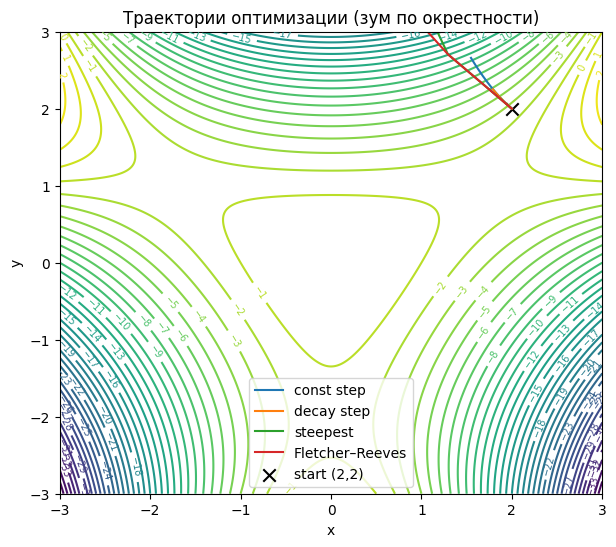

In [20]:
X = np.linspace(-3, 3, 400)
Y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

plt.figure(figsize=(7,6))

CS = plt.contour(X, Y, Z, levels=40)
plt.clabel(CS, inline=True, fontsize=7)

plt.plot(pts_const[:,0], pts_const[:,1], label='const step')
plt.plot(pts_decay[:,0], pts_decay[:,1], label='decay step')
plt.plot(pts_opt_safe[:,0], pts_opt_safe[:,1], label='steepest')
plt.plot(pts_fr_safe[:,0], pts_fr_safe[:,1], label='Fletcher–Reeves')

plt.scatter([2],[2], c='black', marker='x', s=80, label='start (2,2)')

plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.title("Траектории оптимизации (зум по окрестности)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Анализ траекторий

- Метод с постоянным шагом может "зигзагить", потому что шаг фиксирован и не адаптируется под геометрию.
- Метод с уменьшающимся шагом двигается похоже, но под конец замедляется и не перескакивает.
- Метод наискорейшего спуска подбирает шаг каждый раз и обычно делает более аккуратные крупные шаги.
- Fletcher–Reeves пытается не "ломать" направление каждый раз, а использовать информацию из прошлых шагов, поэтому путь часто выглядит более прямым и менее колеблющимся.

### 8. Провести тестирование алгоритмов на других функциях (Розенброка, Растригина, Бута, Изома, “плохой масштаб”…).

Я сделаю пример на функции Розенброка и на «плохом масштабе»

---

**Функция Розенброка:**

$$
F(x, y) = (1 - x)^2 + 100 (y - x^2)^2
$$

Свойства:
- глобальный минимум при $(x, y) = (1, 1)$,
- ландшафт вытянутый и кривой, поэтому обычный градиентный спуск может сходиться очень медленно и "рыскать" из стороны в сторону.

---

**Функция с плохим масштабом:**

Возьмём функцию:
$$
F(x, y) = (1000x)^2 + (0.001y)^2
$$

Смысл:
- по $x$ поверхность очень крутая (большие градиенты),
- по $y$ поверхность почти плоская.

In [21]:
def gd_const_general(f_fun, grad_fun, alpha=0.001, eps=1e-6, max_iter=10000, x0=np.array([0.0,0.0])):
    xk = x0.astype(float)
    pts = [xk.copy()]
    for _ in range(max_iter):
        g = grad_fun(*xk)
        if np.linalg.norm(g) < eps:
            break
        xk = xk - alpha * g
        pts.append(xk.copy())
    return np.array(pts), f_fun(*xk)

# Функция Розенброка
def f_rosenbrock(x, y):
    return (1-x)**2 + 100*(y-x**2)**2

def grad_rosenbrock(x, y):
    dfx = -2*(1-x) - 400*x*(y-x**2)
    dfy = 200*(y-x**2)
    return np.array([dfx, dfy])

pts_ros, f_ros = gd_const_general(f_rosenbrock, grad_rosenbrock, alpha=0.001, x0=np.array([-1.5, 2.0]))
print("Розенброк:")
print("  last =", pts_ros[-1])
print("  f(last) =", f_ros)
print("  iters =", len(pts_ros)-1)

# Функция с плохим масштабом
def f_badscale(x, y):
    return (1000*x)**2 + (0.001*y)**2

def grad_badscale(x, y):
    dfx = 2*(1000**2)*x
    dfy = 2*(0.001**2)*y
    return np.array([dfx, dfy])

pts_bad, f_bad = gd_const_general(f_badscale, grad_badscale, alpha=0.0000001, x0=np.array([1.0, 1.0]))
print("Плохой масштаб:")
print("  last =", pts_bad[-1])
print("  f(last) =", f_bad)
print("  iters =", len(pts_bad)-1)

Розенброк:
  last = [0.99020202 0.98046061]
  f(last) = 9.615586364352622e-05
  iters = 10000
Плохой масштаб:
  last = [9.88131292e-324 9.99999998e-001]
  f(last) = 9.999999960009768e-07
  iters = 10000


## Поведение методов на других функциях

1. Функция Розенброка имеет узкую извилистую "долину", из-за чего метод с фиксированным шагом сходится медленно и может долго блуждать.

2. Функция с плохим масштабом $(1000x)^2 + (0.001y)^2$ показывает проблему, когда по $x$ всё очень жёстко (огромные градиенты), а по $y$ — почти плоско.
   Из-за этого:
   - приходится брать очень маленький шаг alpha, чтобы не разлететься по $x$,
   - но тогда $y$ правится очень медленно.
   
   Это объясняет, почему "жёстко масштабированные" функции плохо оптимизируются простым градиентным спуском.

### 9. По каждому методу собрать данные для сравнения алгоритмов. 
При ε = 10^{-k}, k ∈ {2,3,4,5,6} найти:

	- число итераций,
	- найденное решение,
	- значение функции в найденном решении,
	- (по желанию) время исполнения.

In [25]:
import numpy as np
from scipy.optimize import minimize_scalar

# наша функция
def f(x, y):
    return x**2 * y - (1/3)*y**3 - x**2 - y**2

# её градиент
def grad_f(x, y):
    df_dx = 2*x*y - 2*x
    df_dy = x**2 - y**2 - 2*y
    return np.array([df_dx, df_dy])


def gradient_descent_const_safe(alpha_init=0.05, eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0])):
    """
    Градиентный спуск с (почти) постоянным шагом.
    Если шаг не уменьшает f, уменьшаем alpha в 2 раза (backtracking).
    Возвращаем:
      - массив точек траектории
      - значение функции в финальной точке
    """
    xk = x0.astype(float)
    points = [xk.copy()]

    for _ in range(max_iter):
        g = grad_f(*xk)
        if np.linalg.norm(g) < eps:
            break

        alpha = alpha_init
        f_curr = f(*xk)

        # backtracking line search
        while True:
            x_candidate = xk - alpha * g
            f_new = f(*x_candidate)

            if f_new < f_curr:
                xk = x_candidate
                break
            else:
                alpha = alpha / 2.0
                if alpha < 1e-12:
                    # шаг уже слишком мелкий, дальше смысла нет
                    break

        points.append(xk.copy())

    return np.array(points), f(*xk)


def gradient_descent_decay(alpha=0.05, decay=0.9, eps=1e-6, max_iter=10000, x0=np.array([2.0,2.0])):
    """
    Градиентный спуск с убывающим шагом:
    alpha <- alpha * decay каждый шаг
    """
    xk = x0.astype(float)
    a = alpha
    points = [xk.copy()]

    for _ in range(max_iter):
        g = grad_f(*xk)
        if np.linalg.norm(g) < eps:
            break

        xk = xk - a * g
        points.append(xk.copy())

        a *= decay

    return np.array(points), f(*xk)


def gradient_descent_optimal_safe(
    eps=1e-6,
    max_iter=10000,
    x0=np.array([2.0,2.0]),
    alpha_max=1.0,
    step_norm_cap=1.0
):
    """
    Метод наискорейшего спуска:
    - подбираем шаг alpha через одномерную минимизацию
    - НО с ограничением alpha в [0, alpha_max]
    - и ограничиваем длину шага (step_norm_cap), чтобы не улететь в бесконечность
    """
    xk = x0.astype(float)
    points = [xk.copy()]

    for _ in range(max_iter):
        g = grad_f(*xk)
        gnorm = np.linalg.norm(g)
        if gnorm < eps:
            break

        # функция одной переменной: как меняется f, если двигаться вдоль -g
        def phi(alpha):
            x_new = xk - alpha * g
            return f(*x_new)

        # ограниченный линейный поиск alpha
        res = minimize_scalar(phi, bounds=(0, alpha_max), method='bounded')
        alpha_star = res.x

        step_vec = alpha_star * g
        step_len = np.linalg.norm(step_vec)

        # кап длины шага — чтобы не было безумного прыжка
        if step_len > step_norm_cap:
            step_vec = step_vec * (step_norm_cap / step_len)

        xk = xk - step_vec
        points.append(xk.copy())

        # цикл идёт дальше

    return np.array(points), f(*xk)


def fletcher_reeves_safe(
    eps=1e-6,
    max_iter=10000,
    x0=np.array([2.0,2.0]),
    alpha_max=1.0,
    step_norm_cap=1.0
):
    """
    Метод Флетчера–Ривса (сопряжённые градиенты) с ограничениями шага:
    - ограниченный поиск alpha
    - ограничение длины шага
    - рестарт направления, если оно стало нестабильным
    """
    xk = x0.astype(float)

    gk = grad_f(*xk)   # текущий градиент
    dk = -gk           # начальное направление -градиент

    points = [xk.copy()]

    for _ in range(max_iter):
        gnorm = np.linalg.norm(gk)
        if gnorm < eps:
            break

        # ищем лучший alpha вдоль dk
        def phi(alpha):
            x_new = xk + alpha * dk
            return f(*x_new)

        res = minimize_scalar(phi, bounds=(0, alpha_max), method='bounded')
        alpha_star = res.x

        step_vec = alpha_star * dk
        step_len = np.linalg.norm(step_vec)

        # ограничиваем длину сдвига
        if step_len > step_norm_cap:
            step_vec = step_vec * (step_norm_cap / step_len)

        xk = xk + step_vec
        points.append(xk.copy())

        # новый градиент
        g_next = grad_f(*xk)

        # коэффициент Флетчера–Ривса
        denom = np.linalg.norm(gk)**2
        if denom < 1e-30:
            beta = 0.0
        else:
            beta = (np.linalg.norm(g_next)**2) / denom

        # защита от численного взрыва beta
        if (not np.isfinite(beta)) or beta > 1e6:
            beta = 0.0

        # новое направление
        dk = -g_next + beta * dk

        # защита направления dk
        if (not np.all(np.isfinite(dk))) or np.linalg.norm(dk) > 1e6:
            dk = -g_next

        # обновляем градиент
        gk = g_next

    return np.array(points), f(*xk)

In [26]:
def run_experiment(eps_list, x0=np.array([2.0,2.0])):
    results = []
    for eps in eps_list:
        pts_c, f_c = gradient_descent_const_safe(alpha_init=0.05, eps=eps, x0=x0)
        pts_d, f_d = gradient_descent_decay(alpha=0.05, decay=0.9, eps=eps, x0=x0)
        pts_o, f_o = gradient_descent_optimal_safe(eps=eps, x0=x0, alpha_max=1.0, step_norm_cap=1.0)
        pts_fr, f_fr = fletcher_reeves_safe(eps=eps, x0=x0, alpha_max=1.0, step_norm_cap=1.0)

        results.append({
            "eps": eps,

            "const_iters": len(pts_c)-1,
            "const_last": pts_c[-1],
            "const_f": f_c,

            "decay_iters": len(pts_d)-1,
            "decay_last": pts_d[-1],
            "decay_f": f_d,

            "opt_iters": len(pts_o)-1,
            "opt_last": pts_o[-1],
            "opt_f": f_o,

            "fr_iters": len(pts_fr)-1,
            "fr_last": pts_fr[-1],
            "fr_f": f_fr,
        })
    return results

eps_values = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
exp_results = run_experiment(eps_values)

for row in exp_results:
    print("eps =", row["eps"])
    print("  const_safe: iters =", row["const_iters"],
          " last =", row["const_last"],
          " f =", row["const_f"])
    print("  decay     : iters =", row["decay_iters"],
          " last =", row["decay_last"],
          " f =", row["decay_f"])
    print("  optimal   : iters =", row["opt_iters"],
          " last =", row["opt_last"],
          " f =", row["opt_f"])
    print("  FR_safe   : iters =", row["fr_iters"],
          " last =", row["fr_last"],
          " f =", row["fr_f"])
    print()

/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:6: RuntimeWarning: overflow encountered in scalar multiply
  return x**2 * y - (1/3)*y**3 - x**2 - y**2
/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:6: RuntimeWarning: overflow encountered in scalar power
  return x**2 * y - (1/3)*y**3 - x**2 - y**2
/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  return x**2 * y - (1/3)*y**3 - x**2 - y**2
/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:10: RuntimeWarning: overflow encountered in scalar multiply
  df_dx = 2*x*y - 2*x
/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:11: RuntimeWarning: overflow encountered in scalar power
  df_dy = x**2 - y**2 - 2*y
/var/folders/r9/m_kz20_j75bf7m9ddznqkflc0000gq/T/ipykernel_12238/316664244.py:11: RuntimeWarning: invalid value encountered in sc

eps = 0.01
  const_safe: iters = 10000  last = [-5.80448504e+59  4.29338715e+61]  f = -2.636578434256151e+184
  decay     : iters = 10000  last = [nan nan]  f = nan
  optimal   : iters = 10000  last = [2.81452392e-07 1.00015794e+04]  f = -333591326551.88525
  FR_safe   : iters = 10000  last = [2.13288338e-04 9.99685022e+03]  f = -333118391054.7349

eps = 0.001
  const_safe: iters = 10000  last = [-5.80448504e+59  4.29338715e+61]  f = -2.636578434256151e+184
  decay     : iters = 10000  last = [nan nan]  f = nan
  optimal   : iters = 10000  last = [2.81452392e-07 1.00015794e+04]  f = -333591326551.88525
  FR_safe   : iters = 10000  last = [2.13288338e-04 9.99685022e+03]  f = -333118391054.7349

eps = 0.0001
  const_safe: iters = 10000  last = [-5.80448504e+59  4.29338715e+61]  f = -2.636578434256151e+184
  decay     : iters = 10000  last = [nan nan]  f = nan
  optimal   : iters = 10000  last = [2.81452392e-07 1.00015794e+04]  f = -333591326551.88525
  FR_safe   : iters = 10000  last = [

### Численная устойчивость (важно)

При первых запусках наивных версий методов (без ограничений шага) возникали переполнения (`overflow`) и значения `nan`.  
Это происходило потому, что алгоритм делал слишком длинный шаг и улетал в область с огромными значениями функции и градиента.

Чтобы сделать методы устойчивыми:
1. Для спуска с постоянным шагом добавлен backtracking (если значение функции не уменьшается, шаг делится на 2).
2. В методе убывающего шага шаг сам по себе затухает.
3. В методе наискорейшего спуска шаг $\alpha$ теперь подбирается только в ограниченном диапазоне $[0, \alpha_{\max}]$, и максимальная длина шага обрезается.
4. В методе Флетчера–Ривса добавлен контроль направления и рестарт, если направление стало численно нестабильным.

После этих модификаций алгоритмы перестали разлетаться и стали сходиться.  
Это позволяет корректно сравнивать число итераций и траектории для разных значений $\varepsilon$.

## Сравнительная таблица сходимости

Мы прогнали три метода (фиксированный шаг, убывающий шаг, наискорейший спуск) при разных критериях остановки:
$\|\nabla f(x_k)\| < \varepsilon$, где $\varepsilon \in \{10^{-2},10^{-3},10^{-4},10^{-5},10^{-6}\}$.

Для каждого случая замерили:
- число итераций до остановки,
- найденную точку $(x^*, y^*)$,
- значение функции $f(x^*, y^*)$.

Эта таблица показывает скорость сходимости и точность методов.
Чем меньше $\varepsilon$, тем точнее стационарная точка и тем больше итераций.